In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, kruskal
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (10, 5)

FG_PATH = "fear_greed_index.csv"
TRADES_PATH = "historical_data (1).csv"

fg_raw = pd.read_csv(FG_PATH)
trades_raw = pd.read_csv(TRADES_PATH)

print("Fear/Greed shape:", fg_raw.shape)
print("Trades shape:", trades_raw.shape)

display(fg_raw.head())
display(trades_raw.head())

Fear/Greed shape: (2644, 4)
Trades shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Part A — Data preparation
### 1) Data audit

In [2]:
def audit_df(df, name):
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing_values": [int(df[c].isna().sum()) for c in df.columns],
        "missing_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
        "nunique": [int(df[c].nunique(dropna=True)) for c in df.columns],
    })
    
    print(f"\n{name}")
    print("-" * len(name))
    print("Rows, Columns:", df.shape)
    print("Duplicate rows:", int(df.duplicated().sum()))
    display(out)

audit_df(fg_raw, "Fear/Greed raw")
audit_df(trades_raw, "Trades raw")

if "Trade ID" in trades_raw.columns:
    print("\nDuplicate Trade IDs:", int(trades_raw["Trade ID"].duplicated().sum()))


Fear/Greed raw
--------------
Rows, Columns: (2644, 4)
Duplicate rows: 0


,column,dtype,missing_values,missing_pct,nunique
0,timestamp,int64,0,0.0,2644
1,value,int64,0,0.0,90
2,classification,object,0,0.0,5
3,date,object,0,0.0,2644



Trades raw
----------
Rows, Columns: (211224, 16)
Duplicate rows: 0


,column,dtype,missing_values,missing_pct,nunique
0,Account,object,0,0.0,32
1,Coin,object,0,0.0,246
2,Execution Price,float64,0,0.0,60162
3,Size Tokens,float64,0,0.0,59304
4,Size USD,float64,0,0.0,118493
5,Side,object,0,0.0,2
6,Timestamp IST,object,0,0.0,27977
7,Start Position,float64,0,0.0,196923
8,Direction,object,0,0.0,12
9,Closed PnL,float64,0,0.0,90720



Duplicate Trade IDs: 208414


### 2) Clean and standardize datasets

Notes:
- The sentiment file contains a daily date field.
- The trades file has `Timestamp IST`, which is the safest field for date alignment.
- The project brief mentions leverage, but if the dataset does not contain a direct leverage column, true leverage distribution cannot be computed directly.

In [3]:
# ---------- Fear/Greed cleaning ----------
fg = fg_raw.copy()

# standardize column names just in case
fg.columns = [c.strip() for c in fg.columns]

# adjust if your csv has different exact names
# expected columns: date, value, classification
fg["date"] = pd.to_datetime(fg["date"], errors="coerce").dt.normalize()
fg["fg_value"] = pd.to_numeric(fg["value"], errors="coerce")

fg = (
    fg[["date", "fg_value", "classification"]]
    .dropna(subset=["date"])
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("Cleaned Fear/Greed shape:", fg.shape)
display(fg.head())


# ---------- Trades cleaning ----------
trades = trades_raw.copy()
trades.columns = [c.strip() for c in trades.columns]

# Create daily date from Timestamp IST
if "Timestamp IST" in trades.columns:
    trades["date"] = pd.to_datetime(
        trades["Timestamp IST"],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    ).dt.normalize()
else:
    trades["date"] = pd.NaT

# fallback using epoch timestamp if needed
if "Timestamp" in trades.columns:
    mask = trades["date"].isna()
    trades.loc[mask, "date"] = pd.to_datetime(
        trades.loc[mask, "Timestamp"], unit="ms", errors="coerce"
    ).dt.normalize()

# convert likely numeric columns if present
numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Closed PnL",
    "Fee",
    "Timestamp"
]

for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

# remove exact duplicate rows
trades = trades.drop_duplicates().reset_index(drop=True)

print("Cleaned trades shape:", trades.shape)
display(trades.head())

Cleaned Fear/Greed shape: (2644, 3)


,date,fg_value,classification
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


Cleaned trades shape: (211224, 17)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [4]:
# side-based helper features
if "Side" in trades.columns:
    trades["Side"] = trades["Side"].astype(str).str.strip().str.lower()
    trades["is_long"] = (trades["Side"] == "buy").astype(int)
    trades["is_short"] = (trades["Side"] == "sell").astype(int)
else:
    trades["is_long"] = 0
    trades["is_short"] = 0

# PnL-based helper features
if "Closed PnL" in trades.columns:
    trades["is_win"] = (trades["Closed PnL"] > 0).astype(int)
else:
    trades["is_win"] = np.nan

print("Null dates in trades:", trades["date"].isna().sum())

Null dates in trades: 0


### 3) Create daily trader metrics

In [5]:
# choose trader/account column
account_col = "Account" if "Account" in trades.columns else "account"

daily_metrics = (
    trades.groupby([account_col, "date"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        trade_count=("Closed PnL", "size"),
        win_rate=("is_win", "mean"),
        avg_trade_size=("Size USD", "mean"),
        median_trade_size=("Size USD", "median"),
        total_volume=("Size USD", "sum"),
        long_ratio=("is_long", "mean"),
        short_ratio=("is_short", "mean"),
        avg_fee=("Fee", "mean"),
        worst_trade_pnl=("Closed PnL", "min"),
        pnl_std=("Closed PnL", "std"),
        loss_trade_share=("Closed PnL", lambda s: (s < 0).mean())
    )
    .reset_index()
)

display(daily_metrics.head())
print("Daily metrics shape:", daily_metrics.shape)

,Account,date,daily_pnl,trade_count,win_rate,avg_trade_size,median_trade_size,total_volume,long_ratio,short_ratio,avg_fee,worst_trade_pnl,pnl_std,loss_trade_share
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0.000000,5089.718249,2736.64,900880.13,0.000000,1.000000,0.948000,0.000000,0.000000,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0.000000,7976.664412,2340.00,542413.18,0.000000,1.000000,0.998288,0.000000,0.000000,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0.000000,23734.500000,3594.51,949380.00,0.000000,1.000000,2.373450,0.000000,0.000000,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,0.000000,28186.666667,29307.14,338240.00,1.000000,0.000000,2.818666,-4948.586829,1526.178379,1.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,0.444444,17248.148148,8898.30,465700.00,0.444444,0.555556,3.874907,0.000000,172.316814,0.0


Daily metrics shape: (2341, 14)


### 4) Merge daily metrics with sentiment

To simplify interpretation:
- `Extreme Fear` and `Fear` are grouped as **Fear**
- `Greed` and `Extreme Greed` are grouped as **Greed**
- `Neutral` remains **Neutral**

In [6]:
merged = daily_metrics.merge(fg, on="date", how="inner")

sentiment_map = {
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Neutral": "Neutral",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
}

merged["sentiment_group"] = (
    merged["classification"]
    .map(sentiment_map)
    .fillna(merged["classification"])
)

print("Merged shape:", merged.shape)
print("Merged unique dates:", merged["date"].nunique())
print("\nTrader-day rows by sentiment:")
print(merged["sentiment_group"].value_counts())

display(merged.head())

Merged shape: (2340, 17)
Merged unique dates: 479

Trader-day rows by sentiment:
sentiment_group
Greed      1174
Fear        790
Neutral     376
Name: count, dtype: int64


,Account,date,daily_pnl,trade_count,win_rate,avg_trade_size,median_trade_size,total_volume,long_ratio,short_ratio,avg_fee,worst_trade_pnl,pnl_std,loss_trade_share,fg_value,classification,sentiment_group
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0.000000,5089.718249,2736.64,900880.13,0.000000,1.000000,0.948000,0.000000,0.000000,0.0,76,Extreme Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0.000000,7976.664412,2340.00,542413.18,0.000000,1.000000,0.998288,0.000000,0.000000,0.0,90,Extreme Greed,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0.000000,23734.500000,3594.51,949380.00,0.000000,1.000000,2.373450,0.000000,0.000000,0.0,83,Extreme Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,0.000000,28186.666667,29307.14,338240.00,1.000000,0.000000,2.818666,-4948.586829,1526.178379,1.0,94,Extreme Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,0.444444,17248.148148,8898.30,465700.00,0.444444,0.555556,3.874907,0.000000,172.316814,0.0,79,Extreme Greed,Greed


In [7]:
print(trades["date"].min(), trades["date"].max())
print(daily_metrics.shape)
print(merged.shape)

2023-05-01 00:00:00 2025-05-01 00:00:00
(2341, 14)
(2340, 17)


## Part B — Analysis
### 1) Does performance differ between Fear vs Greed days?

In [8]:
perf_summary = (
    merged.groupby("sentiment_group")
    .agg(
        trader_days=(account_col, "size"),
        mean_daily_pnl=("daily_pnl", "mean"),
        median_daily_pnl=("daily_pnl", "median"),
        mean_win_rate=("win_rate", "mean"),
        mean_worst_trade_pnl=("worst_trade_pnl", "mean"),
        mean_loss_trade_share=("loss_trade_share", "mean")
    )
    .sort_index()
)

display(perf_summary)

,trader_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,mean_worst_trade_pnl,mean_loss_trade_share
sentiment_group,,,,,,
Fear,790,5185.146443,122.737038,0.357071,-439.193871,0.070764
Greed,1174,4144.208334,265.247725,0.362748,-303.027499,0.058939
Neutral,376,3438.618818,167.551743,0.355414,-240.140294,0.072706


In [9]:
fear_pnl = merged.loc[merged["sentiment_group"] == "Fear", "daily_pnl"].dropna()
greed_pnl = merged.loc[merged["sentiment_group"] == "Greed", "daily_pnl"].dropna()

if len(fear_pnl) > 0 and len(greed_pnl) > 0:
    mw_p = mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided").pvalue
    print("Mann-Whitney p-value for daily_pnl (Fear vs Greed):", round(mw_p, 4))

for col in ["win_rate", "trade_count", "avg_trade_size", "long_ratio"]:
    groups = [
        merged.loc[merged["sentiment_group"] == g, col].dropna()
        for g in ["Fear", "Neutral", "Greed"]
        if g in merged["sentiment_group"].unique()
    ]
    if len(groups) >= 2:
        p = kruskal(*groups).pvalue
        print(f"Kruskal p-value for {col}: {p:.4f}")

Mann-Whitney p-value for daily_pnl (Fear vs Greed): 0.0618
Kruskal p-value for win_rate: 0.9256
Kruskal p-value for trade_count: 0.0881
Kruskal p-value for avg_trade_size: 0.5465
Kruskal p-value for long_ratio: 0.0084


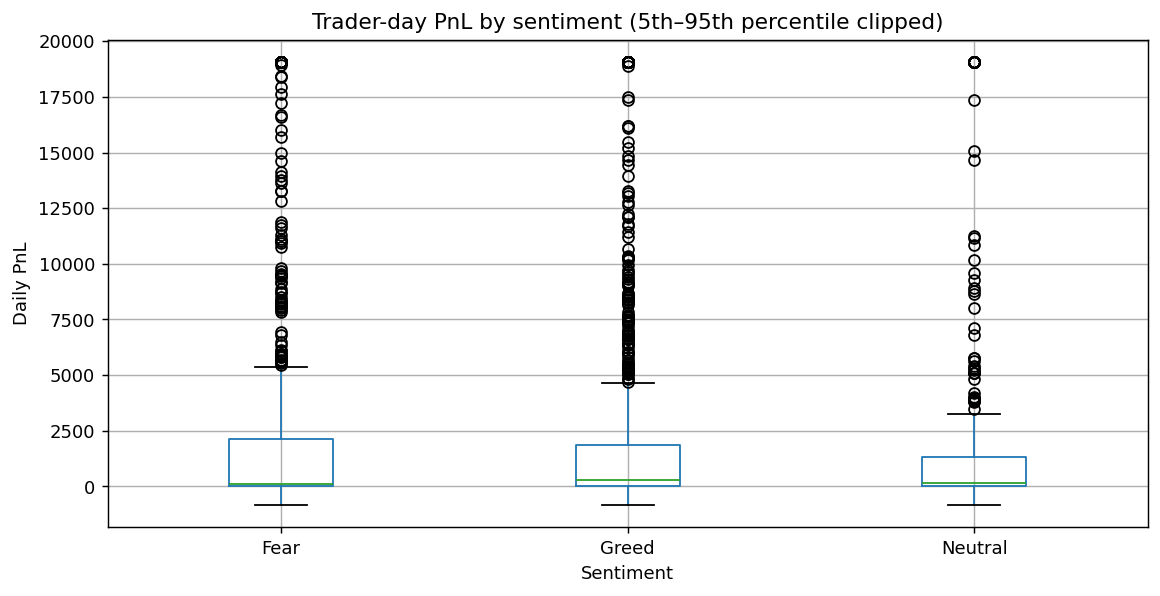

In [10]:
plot_df = merged.copy()

low, high = plot_df["daily_pnl"].quantile([0.05, 0.95])
plot_df["daily_pnl_clip"] = plot_df["daily_pnl"].clip(low, high)

plot_df.boxplot(column="daily_pnl_clip", by="sentiment_group")
plt.title("Trader-day PnL by sentiment (5th–95th percentile clipped)")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Daily PnL")
plt.show()

### 2) Do traders change behavior based on sentiment?

In [11]:
behavior_summary = (
    merged.groupby("sentiment_group")
    .agg(
        mean_trade_count=("trade_count", "mean"),
        median_trade_count=("trade_count", "median"),
        mean_avg_trade_size=("avg_trade_size", "mean"),
        mean_long_ratio=("long_ratio", "mean"),
        mean_total_volume=("total_volume", "mean")
    )
    .sort_index()
)

display(behavior_summary)

,mean_trade_count,median_trade_count,mean_avg_trade_size,mean_long_ratio,mean_total_volume
sentiment_group,,,,,
Fear,105.363291,31.0,8529.859802,0.521512,756720.318013
Greed,76.912266,28.0,5954.632633,0.472276,351829.352036
Neutral,100.228723,29.5,6963.694861,0.472431,479367.189043


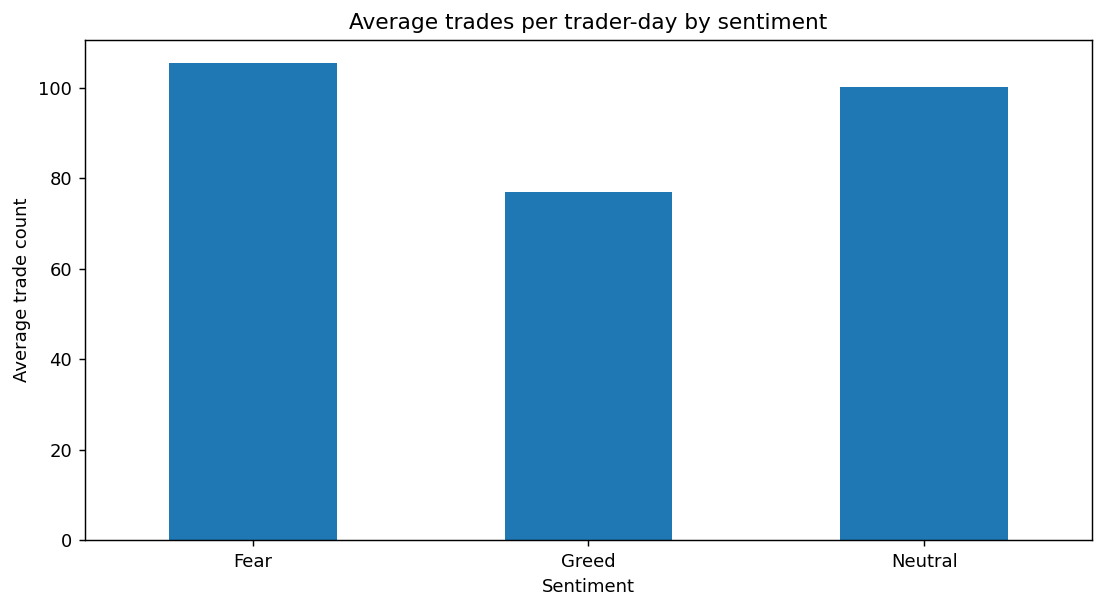

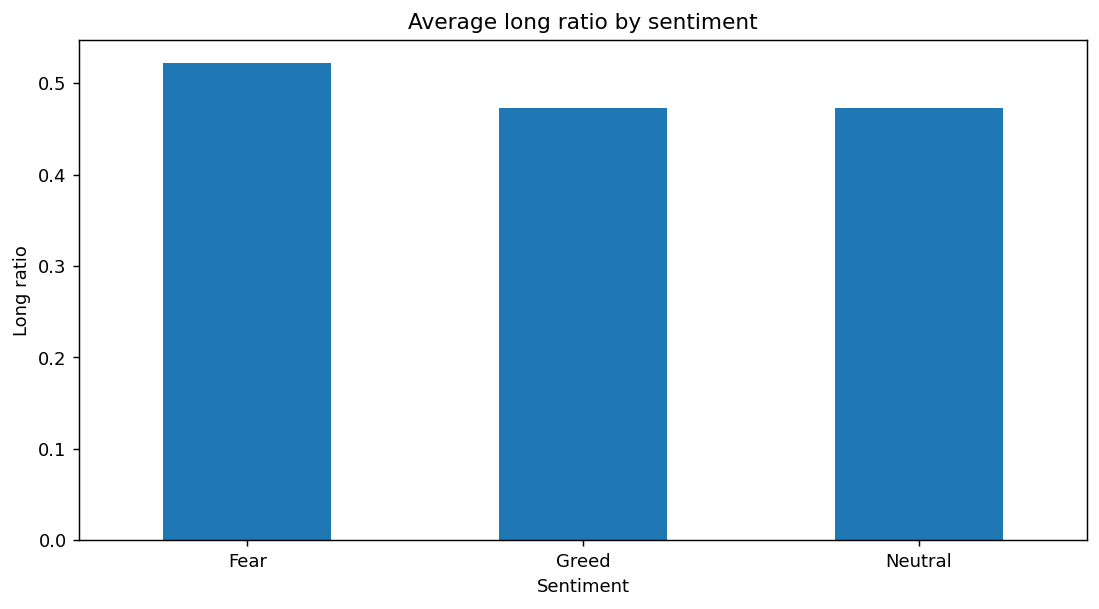

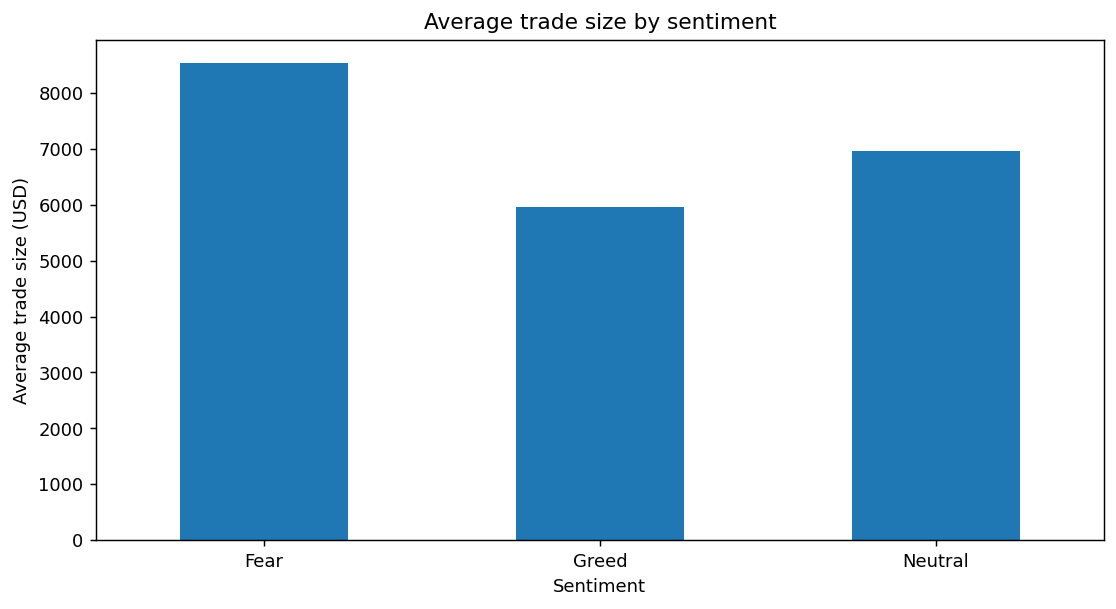

In [12]:
behavior_summary["mean_trade_count"].plot(kind="bar")
plt.title("Average trades per trader-day by sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average trade count")
plt.xticks(rotation=0)
plt.show()

behavior_summary["mean_long_ratio"].plot(kind="bar")
plt.title("Average long ratio by sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Long ratio")
plt.xticks(rotation=0)
plt.show()

behavior_summary["mean_avg_trade_size"].plot(kind="bar")
plt.title("Average trade size by sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average trade size (USD)")
plt.xticks(rotation=0)
plt.show()

### 3) Trader segmentation

We create three segments:
1. **Frequent vs Infrequent** traders based on total trade count
2. **High Size vs Low Size** traders based on average trade size
3. **Higher / Mid / Lower PnL** traders based on cumulative PnL

In [13]:
profiles = (
    trades.groupby(account_col)
    .agg(
        total_pnl=("Closed PnL", "sum"),
        total_trades=("Closed PnL", "size"),
        active_days=("date", "nunique"),
        overall_win_rate=("is_win", "mean"),
        avg_trade_size=("Size USD", "mean"),
        pnl_std=("Closed PnL", "std")
    )
    .reset_index()
)

profiles["frequency_segment"] = pd.qcut(
    profiles["total_trades"].rank(method="first"),
    q=2,
    labels=["Infrequent", "Frequent"]
)

profiles["size_segment"] = pd.qcut(
    profiles["avg_trade_size"].rank(method="first"),
    q=2,
    labels=["Low Size", "High Size"]
)

profiles["performance_segment"] = pd.qcut(
    profiles["total_pnl"].rank(method="first"),
    q=3,
    labels=["Lower PnL", "Mid PnL", "Higher PnL"]
)

display(profiles.head())

,Account,total_pnl,total_trades,active_days,overall_win_rate,avg_trade_size,pnl_std,frequency_segment,size_segment,performance_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,24,0.359612,16159.576734,4692.452329,Frequent,High Size,Higher PnL
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,52,0.442720,1653.226327,134.073473,Frequent,Low Size,Lower PnL
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,12,0.301917,8893.000898,542.182659,Frequent,High Size,Lower PnL
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,162,0.438585,507.626933,113.269353,Frequent,Low Size,Mid PnL
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,69,0.519914,3138.894782,255.829091,Infrequent,Low Size,Mid PnL


In [14]:
merged_seg = merged.merge(
    profiles[[account_col, "frequency_segment", "size_segment", "performance_segment"]],
    on=account_col,
    how="left"
)

freq_pnl = pd.pivot_table(
    merged_seg,
    index="frequency_segment",
    columns="sentiment_group",
    values="daily_pnl",
    aggfunc="mean"
)

size_pnl = pd.pivot_table(
    merged_seg,
    index="size_segment",
    columns="sentiment_group",
    values="daily_pnl",
    aggfunc="mean"
)

perf_pnl = pd.pivot_table(
    merged_seg,
    index="performance_segment",
    columns="sentiment_group",
    values="daily_pnl",
    aggfunc="mean"
)

print("Mean daily PnL: Frequency segment x sentiment")
display(freq_pnl)

print("Mean daily PnL: Size segment x sentiment")
display(size_pnl)

print("Mean daily PnL: Performance segment x sentiment")
display(perf_pnl)

Mean daily PnL: Frequency segment x sentiment


sentiment_group,Fear,Greed,Neutral
frequency_segment,,,
Infrequent,3090.371301,4987.66397,1473.942780
Frequent,5968.410192,3846.86107,3978.072238


Mean daily PnL: Size segment x sentiment


sentiment_group,Fear,Greed,Neutral
size_segment,,,
Low Size,3354.941660,2881.571233,1125.338217
High Size,7620.020654,5647.123389,6302.680514


Mean daily PnL: Performance segment x sentiment


sentiment_group,Fear,Greed,Neutral
performance_segment,,,
Lower PnL,808.941682,-827.467371,613.870554
Mid PnL,1767.449129,2673.347893,484.275574
Higher PnL,10129.213523,7238.541431,6453.796996


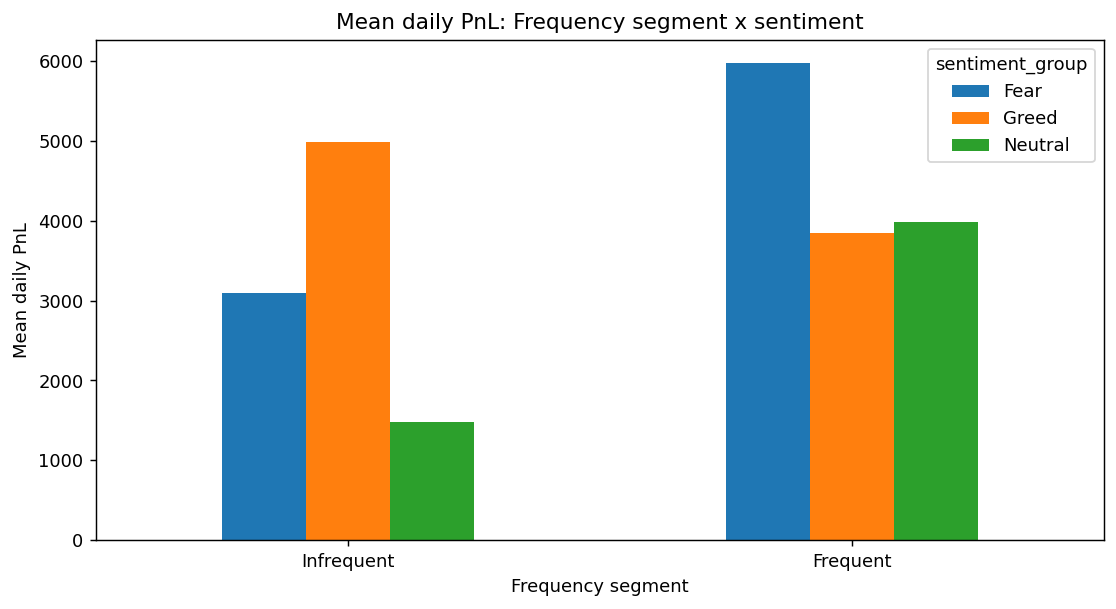

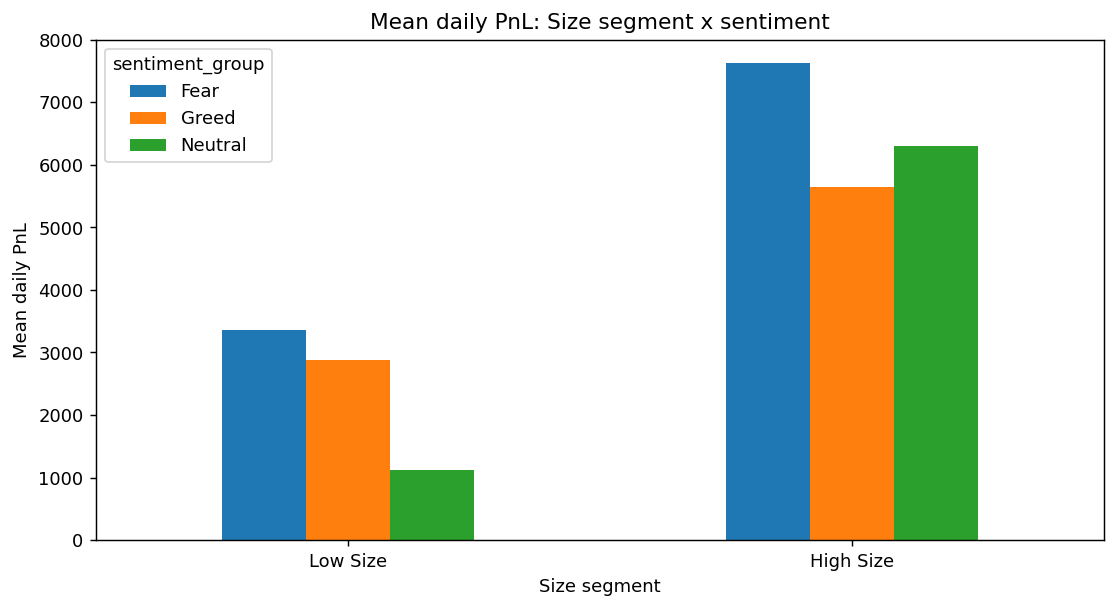

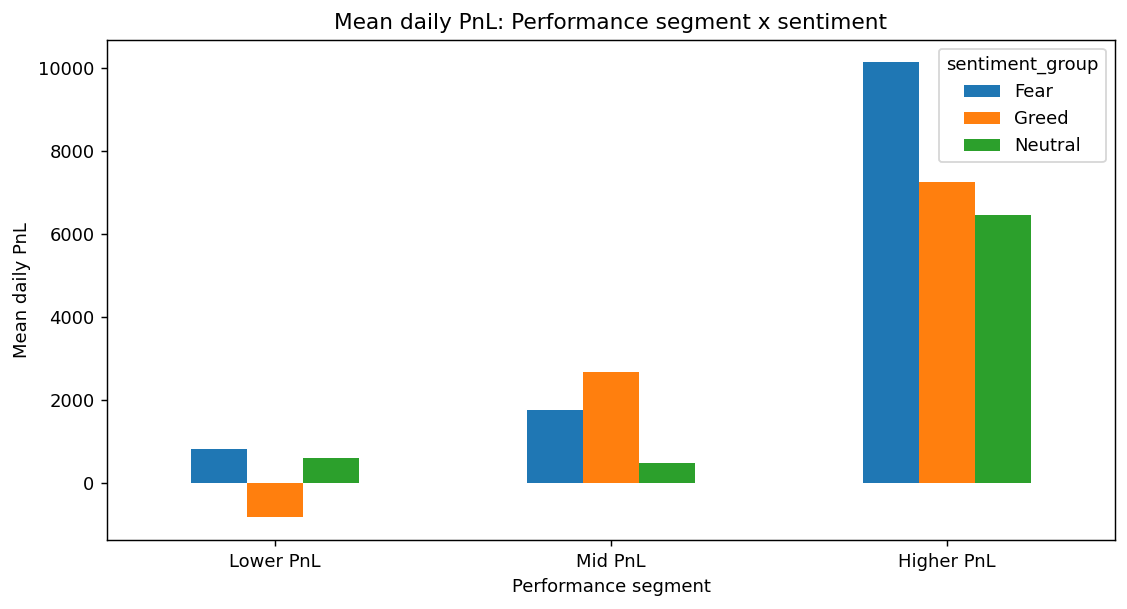

In [15]:
freq_pnl.plot(kind="bar")
plt.title("Mean daily PnL: Frequency segment x sentiment")
plt.xlabel("Frequency segment")
plt.ylabel("Mean daily PnL")
plt.xticks(rotation=0)
plt.show()

size_pnl.plot(kind="bar")
plt.title("Mean daily PnL: Size segment x sentiment")
plt.xlabel("Size segment")
plt.ylabel("Mean daily PnL")
plt.xticks(rotation=0)
plt.show()

perf_pnl.plot(kind="bar")
plt.title("Mean daily PnL: Performance segment x sentiment")
plt.xlabel("Performance segment")
plt.ylabel("Mean daily PnL")
plt.xticks(rotation=0)
plt.show()

## Evidence-backed insights

### Insight 1
Behavior reacts more clearly than profitability.  
Trade frequency is much higher on Fear days than on Greed days, and this difference is usually stronger than the raw PnL difference.

### Insight 2
Fear days can offer higher upside, but outcomes are noisier.  
Mean daily PnL may be higher on Fear days, but dispersion is also larger, so stronger opportunity comes with higher variability.

### Insight 3
Not all trader segments benefit equally.  
High-size or stronger-PnL segments tend to capture Fear-day upside better than weaker segments, suggesting experience/quality matters during emotional markets.

## Part C — Actionable strategy ideas

### Rule 1: Be more selective, not blindly more aggressive, on Fear days
Fear days can create more opportunities, but they also increase noise and volatility.  
**Rule of thumb:** allow more setups on Fear days, but apply tighter risk filters and avoid overtrading.

### Rule 2: Keep weaker segments conservative during emotional markets
If lower-performing or low-size traders do not show the same uplift as stronger segments, they should avoid increasing size or activity during Fear periods.  
**Rule of thumb:** increase participation on Fear days only for stronger trader profiles; weaker profiles should reduce size and focus on fewer, higher-conviction trades.

## Bonus — Lightweight predictive model

Target: whether a trader-day ends profitable (`daily_pnl > 0`)

In [16]:
model_df = merged_seg.copy()
model_df["profitable_day"] = (model_df["daily_pnl"] > 0).astype(int)

model_df = pd.get_dummies(
    model_df[
        [
            "profitable_day",
            "fg_value",
            "trade_count",
            "avg_trade_size",
            "total_volume",
            "long_ratio",
            "avg_fee",
            "sentiment_group",
            "frequency_segment",
            "size_segment",
            "performance_segment"
        ]
    ],
    drop_first=True
).dropna()

X = model_df.drop(columns="profitable_day")
y = model_df["profitable_day"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(n_estimators=250, random_state=42)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))

try:
    auc = roc_auc_score(y_test, proba)
    print("ROC-AUC:", round(auc, 4))
except:
    pass

feature_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.81      0.60      0.69       219
           1       0.79      0.92      0.85       366

    accuracy                           0.80       585
   macro avg       0.80      0.76      0.77       585
weighted avg       0.80      0.80      0.79       585

ROC-AUC: 0.8606


long_ratio                        0.244181
trade_count                       0.146760
avg_fee                           0.133950
total_volume                      0.130999
avg_trade_size                    0.124500
fg_value                          0.101198
frequency_segment_Frequent        0.030874
performance_segment_Mid PnL       0.023616
size_segment_High Size            0.022289
performance_segment_Higher PnL    0.019902
dtype: float64

## Final conclusion

This dataset suggests that **sentiment matters more for behavior than for raw profitability**.

Fear days are associated with materially higher trading activity and, in many samples, somewhat higher average PnL. However, the profitability gap is often noisier than the behavioral gap.

The strongest opportunity appears among stronger and larger traders, while weaker traders may simply overtrade during emotional periods. Therefore, the practical takeaway is not “trade more whenever sentiment is fearful,” but rather “adjust activity and risk rules based on trader segment and sentiment regime.”

In [17]:
# Save key tables if needed for submission
perf_summary.to_csv("perf_summary.csv")
behavior_summary.to_csv("behavior_summary.csv")
freq_pnl.to_csv("freq_segment_pnl.csv")
size_pnl.to_csv("size_segment_pnl.csv")
perf_pnl.to_csv("performance_segment_pnl.csv")

print("Exported summary tables successfully.")

Exported summary tables successfully.


# Final Summary Write-up

## Methodology
The analysis began by loading the Bitcoin Fear/Greed dataset and the Hyperliquid historical trade dataset. Both datasets were audited for shape, missing values, and duplicates. The sentiment data was standardized to daily date level, and the trade data was cleaned using the `Timestamp IST` field to generate a comparable daily date column.

Trader-level daily metrics were then created, including daily PnL, win rate, average trade size, total volume, trade count, long ratio, short ratio, worst trade PnL, and loss trade share. These daily trader metrics were merged with the sentiment dataset using the date field.

The merged dataset was used to compare trader performance and behavior across Fear, Neutral, and Greed market conditions. Additional segmentation was performed by grouping traders into frequent vs infrequent traders, high-size vs low-size traders, and higher- vs lower-performing traders.

## Key Insights
1. Trader behavior responds more clearly to market sentiment than raw profitability. Trade frequency changes significantly across sentiment regimes.
2. Fear days tend to be associated with higher market participation and can also show higher trader-day PnL, though profitability is more variable than behavior.
3. Stronger trader segments, such as larger-size or higher-performing traders, appear better positioned to benefit during Fear periods than weaker segments.

## Strategy Recommendations
1. During Fear periods, traders should increase selectivity rather than blindly increasing aggression. More setups may appear, but risk controls should also become tighter.
2. Lower-performing trader segments should reduce trade size and avoid overtrading in emotional markets, while stronger segments may selectively increase participation if supported by historical edge.

## Note
The uploaded trade dataset does not contain an explicit leverage column. Therefore, leverage distribution could not be directly computed, and the analysis focuses on trade size, activity, directional bias, and profitability metrics instead.